## Adversarial Attacks Series:

### Note 01: Fast Gradient Sign Method(FGSM)

#### Dataset: MNIST

 To create a CNN model you can read this article :

 Simple Convolutional Neural Network (CNN) for Dummies in PyTorch: A Step-by-Step Guide by Mayur Ingole
 
 link: https://medium.com/@myringoleMLGOD/simple-convolutional-neural-network-cnn-for-dummies-in-pytorch-a-step-by-step-guide-6f4109f6df80

In [ ]:
# 0. Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms


In [ ]:
# 1. Setup
class FlexibleCNN(nn.Module):
    def __init__(self):
        super(FlexibleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc1 = None  # Will be created dynamically
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        
        # Dynamically create fc1 if not exists
        if self.fc1 is None:
            flattened_size = x.view(x.size(0), -1).size(1)
            self.fc1 = nn.Linear(flattened_size, 128).to(x.device)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Example instantiation
model = FlexibleCNN()
print(model)

FlexibleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# Step 2: Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5, ))]) # Define preprocessing

trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# To use a dataset in pytorch we need DataLoader:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)


classes = tuple(str(i) for i in range(10))

In [14]:
train_images, train_labels = next(iter(trainloader))
test_images, test_labels = next(iter(testloader))

In [ ]:
# 3. Evaluation model

model.eval()

FlexibleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:

# 4. Define FGSM attack function
def fgsm_attack(image, epsilon, data_grad):
    # Collect the gradient sign
    sign_data_grad = data_grad.sign()
    # Create perturbed image
    perturbed_image = image + epsilon * sign_data_grad
    # Clamp to valid pixel range [0,1]
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


In [ ]:
# 5. Select a correctly classified test image
image, label = testset[0]
image.requires_grad = True
output = model(image.unsqueeze(0))
initial_pred = output.argmax().item()
initial_confidence = torch.softmax(output, dim=1)[0, initial_pred].item()


In [ ]:
# 6. Compute loss and gradients
loss = nn.CrossEntropyLoss()(output, torch.tensor([label]))
model.zero_grad()
loss.backward()
data_grad = image.grad.data


In [ ]:

# 7. Generate adversarial example
epsilon = 0.3
perturbed_image = fgsm_attack(image, epsilon, data_grad)


In [ ]:
# 8. Evaluate on perturbed image
adv_output = model(perturbed_image.unsqueeze(0))
adv_pred = adv_output.argmax().item()
adv_confidence = torch.softmax(adv_output, dim=1)[0, adv_pred].item()


In [ ]:
# 9. Display results
print(f"Clean image: prediction {initial_pred}, confidence {initial_confidence:.4f}")
print(f"Adversarial image: prediction {adv_pred}, confidence {adv_confidence:.4f}")


Clean image: prediction 5, confidence 0.1227
Adversarial image: prediction 6, confidence 0.1070


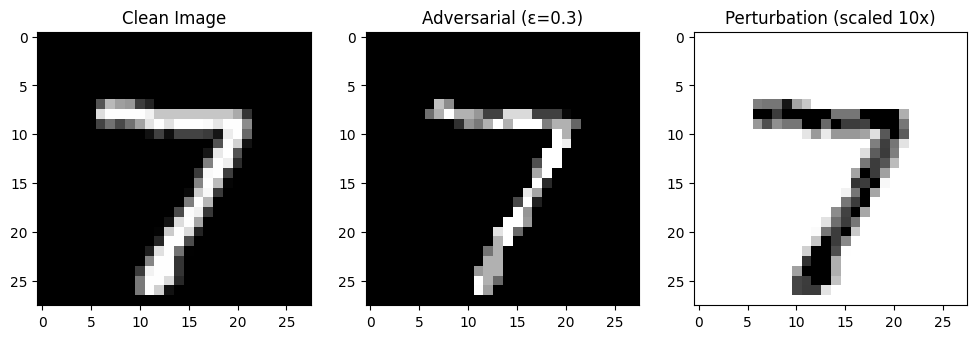

In [ ]:
# 10. Visualize: clean, adversarial, perturbation
perturbation = (perturbed_image - image).detach()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].imshow(image.squeeze().detach().numpy(), cmap='gray')
axes[0].set_title("Clean Image")
axes[1].imshow(perturbed_image.squeeze().detach(), cmap='gray')
axes[1].set_title(f"Adversarial (ε={epsilon})")
axes[2].imshow(perturbation.squeeze() * 10, cmap='gray')  # scaled for visibility
axes[2].set_title("Perturbation (scaled 10x)")
plt.show()

In [ ]:
# 11. Print results
initial_pred = output.argmax().item()  
adv_pred = adv_output.argmax().item() 

# Now compare normally (works fine)
if initial_pred != adv_pred:
    print("✅ Attack succeeded!")

print(f"\n📊 Results:")
print(f"   Original prediction: {initial_pred}")
print(f"   Adversarial prediction: {adv_pred}")
print(f"   Success: {'✅ Attack succeeded!' if initial_pred != adv_pred else '❌ Attack failed'}")
print(f"   Epsilon used: {epsilon}")

✅ Attack succeeded!

📊 Results:
   Original prediction: 5
   Adversarial prediction: 6
   Success: ✅ Attack succeeded!
   Epsilon used: 0.3


In [24]:
# Pseudocode — full implementation in the notebook
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

# Generate adversarial example
epsilon = 0.3
perturbed_image = fgsm_attack(image, epsilon, data_grad)

# Compare predictions
clean_pred = model(image.unsqueeze(0))
adv_pred = model(perturbed_image.unsqueeze(0))